In [18]:
from prophet import Prophet
from prophet.diagnostics import cross_validation,performance_metrics
from prophet.plot import plot_cross_validation_metric, plot_yearly

import pandas as pd
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler, StandardScaler

def adf_test(series, title=""):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f"Augmented Dickey-Fuller Test: {title}")
    result = adfuller(
        series.dropna(), autolag="AIC"
    )  # .dropna() handles differenced data

    labels = ["ADF test statistic", "p-value", "# lags used", "# observations"]
    out = pd.Series(result[0:4], index=labels)

    for key, val in result[4].items():
        out[f"critical value ({key})"] = val

    print(out.to_string())  # .to_string() removes the line "dtype: float64"

    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

def total_mean_error(predictions):
    mean_error = []

    for i in range(len(predictions)):
        if df[3003858507][i] == 0:
            error_value = np.abs((predictions[i]-0.01)/(0.01))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df[3003858507][i]}, erro={error_value}%"
            )
        else:
            error_value = np.abs((predictions[i]-df[3003858507][i])/(df[3003858507][i]))*100
            mean_error.append(error_value)
            print(
                f"predição={predictions[i]}, esperado={df[3003858507][i]}, erro={error_value}%"
            )

    aux = 0

    for i in range(len(mean_error)):
        if mean_error[i] > 200:
            aux = aux
        else:
            aux = mean_error[i] + aux

    final_mean = aux/len(mean_error)

    print(f"Erro percentual médio = {final_mean}%")

In [19]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/IC-Gasto-Fotovoltaico-main/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"

df = pd.concat([df, df])
with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.precision",
    3,
):
    print(df)

           3003858507 3001084033 3011373971 3001449459 3011504476
idx                                                              
2019-06-01     1246.0     7160.0      440.0      960.0     1560.0
2019-07-01     1081.0     6520.0      600.0      920.0     1280.0
2019-08-01     1184.0     6840.0      680.0     1120.0     1360.0
2019-09-01     1549.0     7440.0      760.0     1040.0     1680.0
2019-10-01     2045.0     6920.0      560.0     1120.0     1680.0
2019-11-01     4017.0     6920.0      520.0     1240.0     2920.0
2019-12-01     2386.0     7240.0      320.0     1000.0     1960.0
2020-01-01     4239.0     6560.0      440.0     1120.0     2280.0
2020-02-01     2854.0     7440.0      280.0     1200.0     2480.0
2020-03-01     3208.0     7440.0      320.0     1360.0     2240.0
2020-04-01     1048.0     5640.0      440.0     1080.0     1480.0
2020-05-01     1313.0     4880.0        0.0     1040.0     1280.0
2020-06-01     1174.0     5080.0        0.0     1320.0     1240.0
2020-07-01

In [20]:
new_index = pd.date_range(start=df.index.min(), periods=len(df), freq="MS")

df.index = new_index

In [21]:
df.reset_index(inplace=True)
df = df.rename(columns={"index": "DS"})

df.columns = ["ds", "y1", "y2", "y3", "y4", "y5"]

df["y1"] = df["y1"].astype(int)
df["y2"] = df["y2"].astype(int)
df["y3"] = df["y3"].astype(int)
df["y4"] = df["y4"].astype(int)
df["y5"] = df["y5"].astype(int)

df.columns = ["ds", "y", "y2", "y3", "y4", "y5"]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      90 non-null     datetime64[ns]
 1   y       90 non-null     int64         
 2   y2      90 non-null     int64         
 3   y3      90 non-null     int64         
 4   y4      90 non-null     int64         
 5   y5      90 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 4.3 KB


In [22]:
train = df.iloc[:80]
test = df.iloc[79:]

m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)


m.fit(train)
future = m.make_future_dataframe(periods=12,freq='MS')
forecast = m.predict(future)

18:33:59 - cmdstanpy - INFO - Chain [1] start processing
18:34:06 - cmdstanpy - INFO - Chain [1] done processing


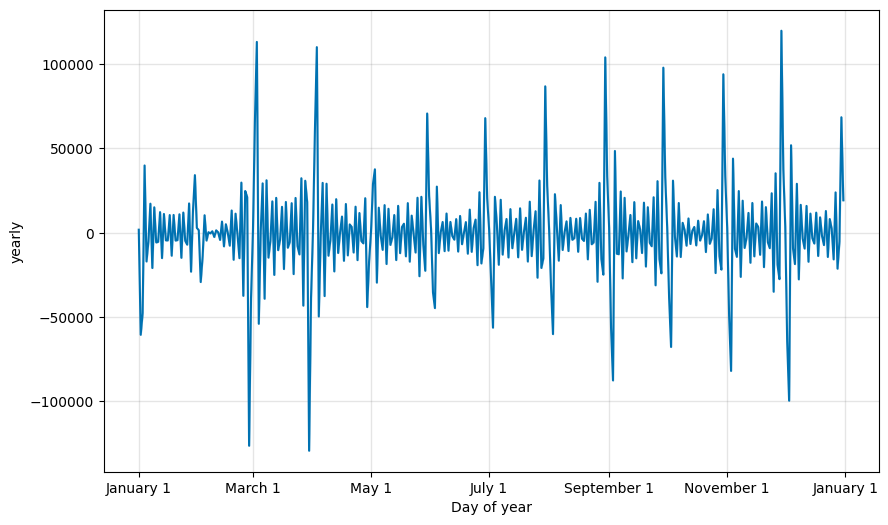

In [23]:
a = plot_yearly(m)

<Axes: xlabel='ds'>

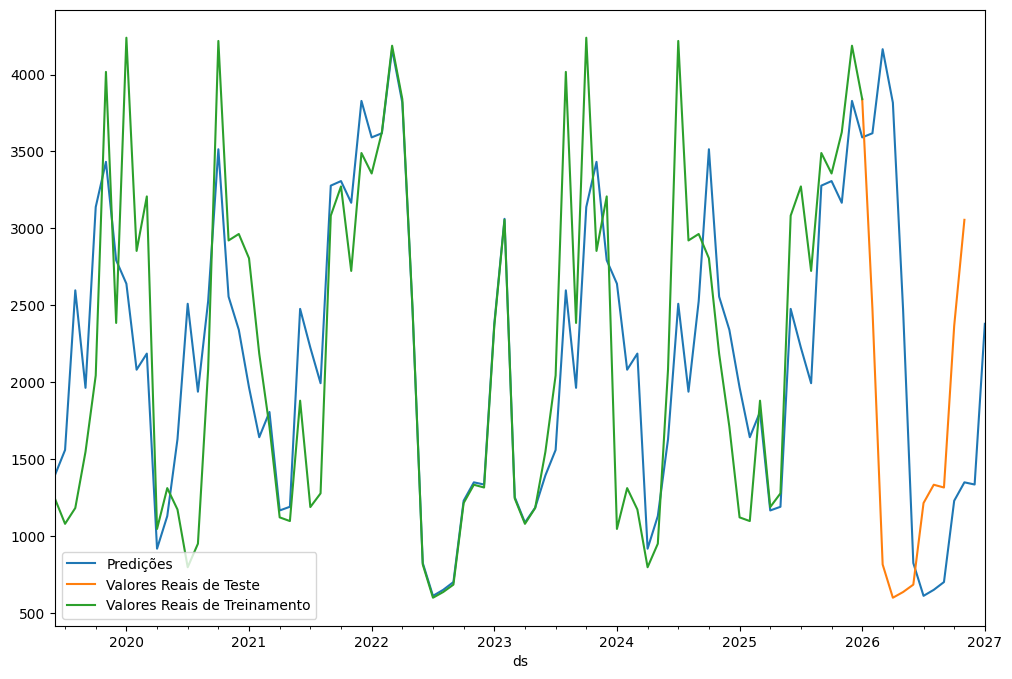

In [24]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
test.plot(x='ds',y='y',label='Valores Reais de Teste',legend=True,ax=ax)
train.plot(x='ds',y='y',label='Valores Reais de Treinamento',legend=True,ax=ax)

In [25]:
df_cv = cross_validation(m,initial="36 days",period="36 days",horizon="12 days")

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.

18:34:08 - cmdstanpy - INFO - Chain [1] start processing
18:34:15 - cmdstanpy - INFO - Chain [1] done processing

18:34:15 - cmdstanpy - INFO - Chain [1] start processing
18:34:20 - cmdstanpy - INFO - Chain [1] done processing

18:34:21 - cmdstanpy - INFO - Chain [1] start processing
18:34:42 - cmdstanpy - INFO - Chain [1] done processing

18:34:42 - cmdstanpy - INFO - Chain [1] start processing
18:35:24 - cmdstanpy - INFO - Chain [1] done processing

18:35:24 - cmdstanpy - INFO - Chain [1] start processing
18:35:39 - cmdstanpy - INFO - Chain [1] done processing

18:35:40 - cmdstanpy - INFO - Chain [1] start processing
18:36:15 - cmdstanpy - INFO - Chain [1] done processing

18:36:15 - cmdstanpy - INFO - Chain [1] start processing
18:38:53 - cmdstanpy - INFO - Chain [1] done processing

18:38:53 - cmdstanpy - INFO - Chain [1] start processing
18:39:05 - cmdstanpy - INFO - Chain [1] 

In [26]:
performance_metrics(df_cv)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,12 days,9.023347e+08,30038.886359,14710.449333,9.688651,1.501743,1.135706,0.153846


In [27]:
m = Prophet(growth='flat', seasonality_mode='additive',yearly_seasonality=150)

m.fit(df)

future = m.make_future_dataframe(periods=48,freq='MS')

forecast = m.predict(future)

forecast.head()

18:52:47 - cmdstanpy - INFO - Chain [1] start processing
18:52:51 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-06-01,124.669414,436.212980,2330.721064,124.669414,124.669414,1270.052950,1270.052950,1270.052950,1270.052950,1270.052950,1270.052950,0.0,0.0,0.0,1394.722364
1,2019-07-01,124.669414,551.326002,2550.928479,124.669414,124.669414,1436.157222,1436.157222,1436.157222,1436.157222,1436.157222,1436.157222,0.0,0.0,0.0,1560.826636
2,2019-08-01,124.669414,1649.759905,3608.711975,124.669414,124.669414,2473.105615,2473.105615,2473.105615,2473.105615,2473.105615,2473.105615,0.0,0.0,0.0,2597.775029
3,2019-09-01,124.669414,969.897803,2886.028302,124.669414,124.669414,1838.964339,1838.964339,1838.964339,1838.964339,1838.964339,1838.964339,0.0,0.0,0.0,1963.633753
4,2019-10-01,124.669414,2125.940027,4043.154019,124.669414,124.669414,3014.864557,3014.864557,3014.864557,3014.864557,3014.864557,3014.864557,0.0,0.0,0.0,3139.533971


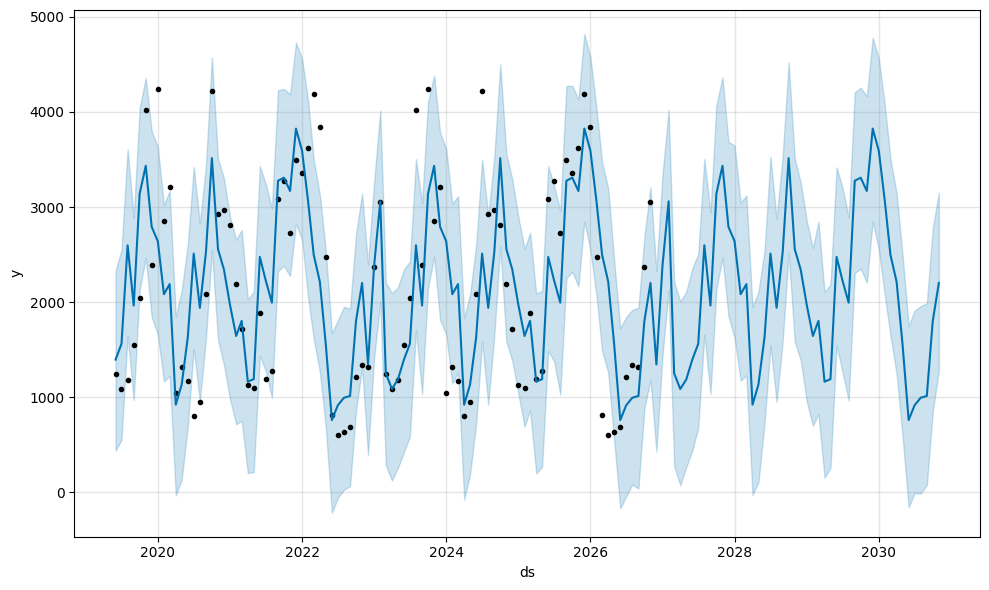

In [28]:
m.plot(forecast);

<Axes: xlabel='ds'>

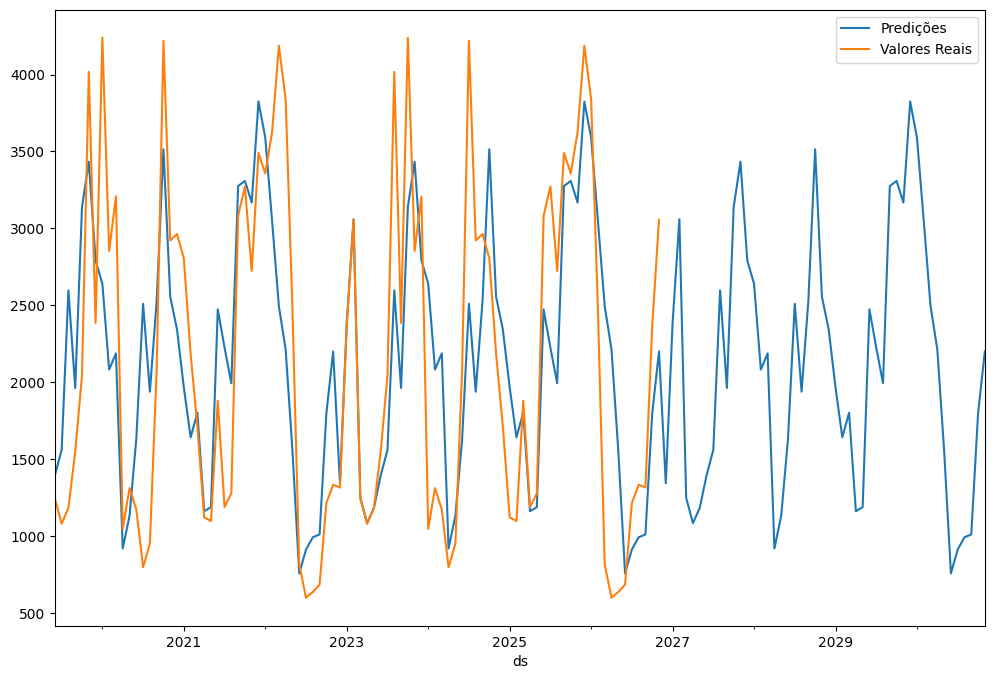

In [29]:
ax = forecast.plot(x='ds', y='yhat', label='Predições', legend=True, figsize=(12,8))
df.plot(x='ds',y='y',label='Valores Reais',legend=True,ax=ax)